# EDA

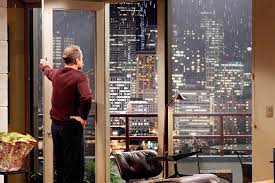

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
os.listdir("data")

The dataset was successfully located in the project directory and loaded from the local data/ folder.
This confirms that the working directory and relative file paths are correctly configured.

The file used for this analysis is:
	•	data/kc_house_sales_joined.csv

In [2]:
df = pd.read_csv("data/kc_house_sales_joined.csv")
df.head()

,sale_id,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2,2014-12-09,538000.0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,3,2015-02-25,180000.0,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,4,2014-12-09,604000.0,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,5,2015-02-18,510000.0,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


The dataset was loaded into a pandas DataFrame using pd.read_csv().

A preview of the first few rows confirms:
	•	The data was read correctly
	•	Column names are present
	•	Values align with expectations (dates, prices, numeric house attributes)

In [3]:
df.shape

(21597, 22)

In [4]:
df.columns

Index(['sale_id', 'date', 'price', 'house_id', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   house_id       21597 non-null  int64  
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        21597 non-null  int64  
 18  lat   

In [6]:
df.describe()

,sale_id,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000000,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,...,21597.000000,21597.000000,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,10799.000000,5.402966e+05,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,...,7.657915,1788.596842,291.857224,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512
std,6234.661218,3.673681e+05,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,...,1.173200,827.759761,442.490863,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950
min,1.000000,7.800000e+04,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,...,3.000000,370.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5400.000000,3.220000e+05,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,10799.000000,4.500000e+05,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,16198.000000,6.450000e+05,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21597.000000,7.700000e+06,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Basic structural inspection was performed using standard pandas methods.

Key observations:
	•	The dataset contains multiple thousands of rows and over 20 columns
	•	Most columns are numeric (int or float)
	•	There is a mix of continuous variables (e.g. price, square footage) and encoded categorical variables (e.g. grade, condition, waterfront)
	•	A unique sale identifier is present (sale_id)

The following aspects were inspected:
	•	Shape of the dataset
	•	Column names
	•	Data types and non-null counts
	•	Summary statistics for numeric columns

In [7]:
df.isna().sum().sort_values(ascending=False)

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
sale_id             0
grade               0
sqft_living15       0
long                0
lat                 0
zipcode             0
yr_built            0
sqft_above          0
condition           0
date                0
floors              0
sqft_lot            0
sqft_living         0
bathrooms           0
bedrooms            0
house_id            0
price               0
sqft_lot15          0
dtype: int64

Missing values were checked across all columns.

Findings:
	•	Most columns are complete
	•	Some columns contain missing or zero-like values (e.g. renovation year)
	•	These will require attention during the data cleaning phase

No cleaning or imputation was performed at this stage; the goal was only to identify potential data quality issues.

In [8]:
df["date"].dtype

dtype('O')

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df["date"].dtype

dtype('<M8[ns]')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique().sort_values()

waterfront           2
view                 5
condition            5
floors               6
grade               11
bedrooms            12
bathrooms           29
yr_renovated        70
zipcode             70
yr_built           116
sqft_basement      303
date               372
long               752
sqft_living15      777
sqft_above         942
sqft_living       1034
price             3622
lat               5033
sqft_lot15        8682
sqft_lot          9776
house_id         21420
sale_id          21597
dtype: int64

Binary and low-cardinality categorical features

Several variables have very few unique values despite being numeric:
	•	waterfront (2) clearly represents a binary feature.
	•	view (5) and condition (5) represent ordered categorical variables.
	•	floors (6) and grade (11) are ordinal features describing property characteristics.
	•	bedrooms (12) and bathrooms (29) take on a limited set of discrete values and are best treated as count or ordinal variables rather than continuous measures.

These features should be handled as categorical or ordinal variables in analysis and modeling, not as continuous numeric inputs.


Temporal and renovation-related features
	•	yr_renovated (70) likely contains many zero values and sporadic renovation years, suggesting missing or sparse information.
	•	yr_built (116) represents construction year and behaves as a numeric temporal feature.
	•	date (372) indicates multiple transaction dates and was later converted to a datetime type to enable time-based analysis.

Size-related continuous features

Variables related to property size show high variability:
	•	sqft_living, sqft_above, sqft_lot, sqft_lot15, and sqft_living15 have hundreds to thousands of unique values.
	•	These should be treated as continuous numerical variables and may benefit from scaling or transformation.

This unique-value analysis highlights a mix of:
	•	Binary and ordinal categorical variables
	•	Continuous numerical features
	•	Temporal and spatial attributes
	•	Explicit identifier columns

Understanding these distinctions is essential for appropriate preprocessing, encoding strategies, and model selection in later stages of the analysis.